# FraudGraph — Stage 1: EDA & XGBoost Baselines

IEEE-CIS Fraud Detection. We merge the two training files, explore the data,
apply a strict temporal split, engineer four behavioral features, and train
**two** XGBoost baselines:

- **lean** — 8 explainable features (matched to the GNN's hand-built signals)
- **full** — every usable IEEE-CIS column (the strong tabular ceiling)

Both are logged to MLflow. The GNN in Stage 3 is compared against both:
lean isolates "did clever features help", full isolates "did graph structure
add anything on top of a strong tabular model" (same features, graph = only delta).

## 0. Setup

In [22]:
!pip install -q mlflow

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import mlflow, pickle
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

pd.set_option("display.max_columns", 200)
DATA = "/kaggle/input/competitions/ieee-fraud-detection"
OUT = "/kaggle/working"
print("files:", os.listdir(DATA) if os.path.isdir(DATA) else "PATH NOT FOUND — fix DATA")

files: ['sample_submission.csv', 'test_identity.csv', 'train_identity.csv', 'test_transaction.csv', 'train_transaction.csv']


## 1. Load & merge

In [24]:
txn = pd.read_csv(f"{DATA}/train_transaction.csv")
idn = pd.read_csv(f"{DATA}/train_identity.csv")
df = txn.merge(idn, on="TransactionID", how="left")
print("transactions:", txn.shape)
print("identity:    ", idn.shape)
print("merged:      ", df.shape)
print("identity coverage: {:.1%}".format(df["DeviceInfo"].notna().mean()))

transactions: (590540, 394)
identity:     (144233, 41)
merged:       (590540, 434)
identity coverage: 20.1%


## 2. EDA

In [25]:
fraud_rate = df["isFraud"].mean()
print(f"Rows: {len(df):,}")
print(f"Fraud: {df['isFraud'].sum():,} ({fraud_rate:.3%})")
print(f"Legit: {(df['isFraud']==0).sum():,}")
print(f"Imbalance ratio (legit/fraud): {(1-fraud_rate)/fraud_rate:.1f}")

Rows: 590,540
Fraud: 20,663 (3.499%)
Legit: 569,877
Imbalance ratio (legit/fraud): 27.6


In [26]:
miss = df.isna().mean().sort_values(ascending=False)
print("Columns >90% missing:", int((miss > 0.9).sum()))
print("Columns  <1% missing:", int((miss < 0.01).sum()))
miss.head(15)

Columns >90% missing: 12
Columns  <1% missing: 111


id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
dtype: float64

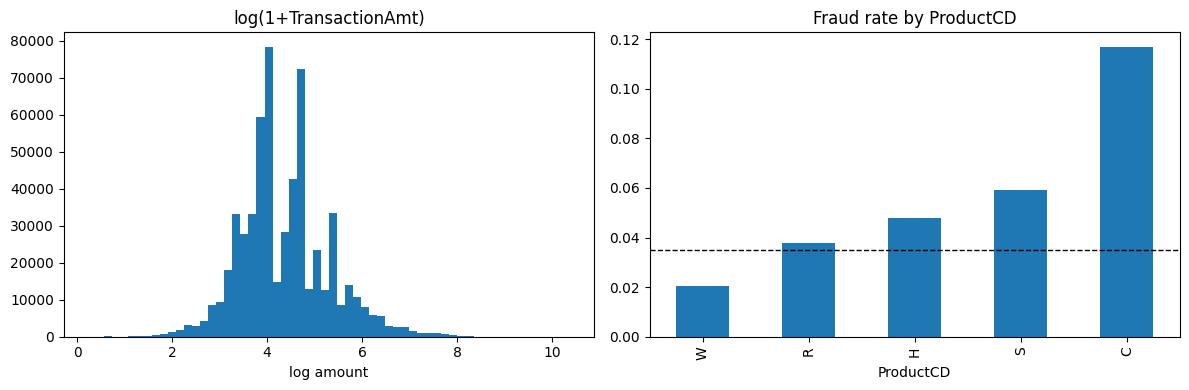

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.log1p(df["TransactionAmt"]), bins=60)
ax[0].set_title("log(1+TransactionAmt)"); ax[0].set_xlabel("log amount")
by_prod = df.groupby("ProductCD")["isFraud"].mean().sort_values()
by_prod.plot(kind="bar", ax=ax[1]); ax[1].set_title("Fraud rate by ProductCD")
ax[1].axhline(fraud_rate, color="k", ls="--", lw=1)
plt.tight_layout(); plt.show()

In [28]:
print("Fraud rate by card4 (network):")
print(df.groupby("card4")["isFraud"].mean().sort_values(ascending=False))
day = (df["TransactionDT"] // 86400)
rate_by_day = df.groupby(day)["isFraud"].mean()
print("\nFraud rate over time (by day bucket, first/last 5):")
print(rate_by_day.head()); print(rate_by_day.tail())

Fraud rate by card4 (network):
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64

Fraud rate over time (by day bucket, first/last 5):
TransactionDT
1    0.021866
2    0.032976
3    0.028386
4    0.028494
5    0.032038
Name: isFraud, dtype: float64
TransactionDT
178    0.042553
179    0.030317
180    0.037433
181    0.044542
182    0.043210
Name: isFraud, dtype: float64


## 3. Temporal split

`TransactionDT` is seconds from a reference point, so sorting by it = chronological
order. First 80% -> train, last 20% -> test. No shuffling: a random split would let
the same card appear in both train and test, leaking future information.

In [29]:
df = df.sort_values("TransactionDT").reset_index(drop=True)
cutoff = df["TransactionDT"].quantile(0.80)
is_train = df["TransactionDT"] <= cutoff
print(f"Split cutoff TransactionDT: {int(cutoff):,}")
print(f"Train rows: {is_train.sum():,}  |  Test rows: {(~is_train).sum():,}")
print(f"Train fraud rate: {df.loc[is_train,'isFraud'].mean():.3%}")
print(f"Test  fraud rate: {df.loc[~is_train,'isFraud'].mean():.3%}")

Split cutoff TransactionDT: 12,192,853
Train rows: 472,432  |  Test rows: 118,108
Train fraud rate: 3.514%
Test  fraud rate: 3.441%


## 4. Feature engineering (the 4 behavioral signals)

Each is computed point-in-time (past-only) so nothing leaks the future:
velocity (rolling counts per card), amount z-score (vs the card's prior stats),
hour of day, and card-merchant pair frequency.

In [30]:
df["card1"] = df["card1"].fillna(-999)
df["addr1"] = df["addr1"].fillna(-999)
df["dt"] = pd.to_datetime(df["TransactionDT"], unit="s")

df["hour"] = ((df["TransactionDT"] // 3600) % 24).astype(int)
df["cm_freq"] = df.groupby(["card1", "ProductCD", "addr1"]).cumcount()

g = df.groupby("card1")["TransactionAmt"]
mean_prev = g.transform(lambda s: s.expanding().mean().shift())
std_prev = g.transform(lambda s: s.expanding().std().shift())
df["amt_zscore"] = ((df["TransactionAmt"] - mean_prev) / std_prev)
df["amt_zscore"] = df["amt_zscore"].replace([np.inf, -np.inf], np.nan).fillna(0)

In [31]:
df = df.sort_values(["card1", "dt"])
roll = df.set_index("dt").groupby("card1")["TransactionAmt"]
df["velocity_1h"] = roll.rolling("1h").count().values
df["velocity_6h"] = roll.rolling("6h").count().values
df["velocity_24h"] = roll.rolling("24h").count().values
df = df.sort_values("TransactionDT").reset_index(drop=True)
is_train = df["TransactionDT"] <= cutoff
print(df["velocity_24h"].describe())

count    590540.000000
mean         19.803627
std          45.610592
min           1.000000
25%           2.000000
50%           6.000000
75%          20.000000
max         881.000000
Name: velocity_24h, dtype: float64


## 5. Helpers + MLflow logbook

In [33]:
mlflow.set_tracking_uri(f"sqlite:///{OUT}/mlflow.db")
mlflow.set_experiment("fraudgraph")

def evaluate(model, X_te, y_te):
    p = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_te, p)
    metrics = {
        "auc": roc_auc_score(y_te, p),
        "average_precision": average_precision_score(y_te, p),
        "precision_at_10recall": float(prec[np.argmin(np.abs(rec - 0.10))]),
    }
    for k, v in metrics.items():
        print(f"  {k:24s} {v:.4f}")
    return metrics

def log_run(name, params, metrics):
    with mlflow.start_run(run_name=name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
    print(f"  logged MLflow run: {name}")

COMMON = dict(n_estimators=500, max_depth=6, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8,
              eval_metric="auc", tree_method="hist", n_jobs=-1)

2026/07/02 00:43:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/02 00:43:43 INFO mlflow.store.db.utils: Updating database tables
2026/07/02 00:43:46 INFO mlflow.tracking.fluent: Experiment with name 'fraudgraph' does not exist. Creating a new experiment.


## 6. Baseline A — XGBoost lean (8 features)

In [34]:
LEAN = ["TransactionAmt", "ProductCD", "hour",
        "velocity_1h", "velocity_6h", "velocity_24h", "amt_zscore", "cm_freq"]
prod_map = {c: i for i, c in enumerate(sorted(df["ProductCD"].dropna().unique()))}

Xl = df[LEAN].copy()
Xl["ProductCD"] = Xl["ProductCD"].map(prod_map).fillna(-1).astype(int)
y = df["isFraud"]
med_lean = Xl[is_train].median()
Xl = Xl.fillna(med_lean)

Xl_tr, Xl_te = Xl[is_train], Xl[~is_train]
y_tr, y_te = y[is_train], y[~is_train]
pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
print("scale_pos_weight:", round(pos_w, 1))

m_lean = xgb.XGBClassifier(scale_pos_weight=float(pos_w), **COMMON)
m_lean.fit(Xl_tr, y_tr, eval_set=[(Xl_te, y_te)], verbose=100)
print("\nLean baseline:")
met_lean = evaluate(m_lean, Xl_te, y_te)
log_run("xgboost_baseline", {**COMMON, "n_features": len(LEAN), "feature_set": "lean"}, met_lean)
print("\nTop features:")
print(pd.Series(m_lean.feature_importances_, index=LEAN).sort_values(ascending=False))

scale_pos_weight: 27.5
[0]	validation_0-auc:0.74152
[100]	validation_0-auc:0.77762
[200]	validation_0-auc:0.77702
[300]	validation_0-auc:0.77550
[400]	validation_0-auc:0.77166
[499]	validation_0-auc:0.76893

Lean baseline:
  auc                      0.7689
  average_precision        0.1391
  precision_at_10recall    0.2495
  logged MLflow run: xgboost_baseline

Top features:
ProductCD         0.516291
TransactionAmt    0.119297
amt_zscore        0.069018
velocity_1h       0.065325
velocity_24h      0.065174
cm_freq           0.061982
hour              0.057477
velocity_6h       0.045436
dtype: float32


## 7. Full feature matrix

Every usable column: all numeric fields (`C*`, `D*`, `V*`, `card*`, `dist*`, +
our engineered ones) plus label-encoded categoricals (`ProductCD`, `card4/6`,
emaildomains, `M*`, `DeviceType/Info`, `id_*` strings). XGBoost handles residual
NaNs natively; we still median-fill numerics (fit on train) for a clean matrix.
This exact recipe is saved and reused for the GNN's transaction-node features.

In [35]:
drop_cols = ["TransactionID", "isFraud", "TransactionDT", "dt"]
cat_cols = [c for c in df.columns if df[c].dtype == "object" and c not in drop_cols]
num_cols = [c for c in df.columns
            if c not in drop_cols + cat_cols and str(df[c].dtype) != "datetime64[ns]"]

cat_maps = {}
Xf = df[num_cols + cat_cols].copy()
for c in cat_cols:
    m = {v: i for i, v in enumerate(sorted(Xf[c].dropna().unique(), key=str))}
    cat_maps[c] = m
    Xf[c] = Xf[c].map(m).fillna(-1).astype("int32")

med_full = Xf.loc[is_train, num_cols].median()
Xf[num_cols] = Xf[num_cols].fillna(med_full)
feat_full = num_cols + cat_cols
print(f"Full matrix: {Xf.shape}  ({len(num_cols)} numeric + {len(cat_cols)} categorical)")

Full matrix: (590540, 437)  (406 numeric + 31 categorical)


## 8. Baseline B — XGBoost full

In [36]:
Xf_tr, Xf_te = Xf[is_train], Xf[~is_train]
m_full = xgb.XGBClassifier(scale_pos_weight=float(pos_w), **COMMON)
m_full.fit(Xf_tr, y_tr, eval_set=[(Xf_te, y_te)], verbose=100)
print("\nFull baseline:")
met_full = evaluate(m_full, Xf_te, y_te)
log_run("xgboost_full", {**COMMON, "n_features": len(feat_full), "feature_set": "full"}, met_full)
print("\nTop 20 features:")
print(pd.Series(m_full.feature_importances_, index=feat_full).sort_values(ascending=False).head(20))

[0]	validation_0-auc:0.82371
[100]	validation_0-auc:0.88938
[200]	validation_0-auc:0.90133
[300]	validation_0-auc:0.90414
[400]	validation_0-auc:0.90559
[499]	validation_0-auc:0.90667

Full baseline:
  auc                      0.9067
  average_precision        0.5241
  precision_at_10recall    0.9464
  logged MLflow run: xgboost_full

Top 20 features:
V258     0.129906
V218     0.056013
V91      0.052453
V294     0.044733
V70      0.037121
V201     0.024345
C8       0.018974
C4       0.013598
V308     0.013538
V187     0.012764
V69      0.012511
V257     0.011842
V317     0.010860
C14      0.009695
card6    0.009394
V128     0.008675
V141     0.007732
V49      0.006209
id_34    0.006195
V283     0.006180
dtype: float32


## 9. Save artifacts

In [37]:
m_lean.save_model(f"{OUT}/xgb_lean.json")
m_full.save_model(f"{OUT}/xgb_full.json")

preprocessing = {
    "split_cutoff": int(cutoff),
    "lean_features": LEAN,
    "prod_map": prod_map,
    "med_lean": med_lean.to_dict(),
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "cat_maps": cat_maps,
    "med_full": med_full.to_dict(),
    "feat_full": feat_full,
    "amt_mean_train": float(df.loc[is_train, "TransactionAmt"].mean()),
    "amt_std_train": float(df.loc[is_train, "TransactionAmt"].std()),
}
with open(f"{OUT}/preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessing, f)

sample = df.loc[~is_train, ["TransactionID", "TransactionAmt", "ProductCD", "card1",
                            "addr1", "DeviceInfo", "TransactionDT", "isFraud"]].sample(500, random_state=42)
sample.to_csv(f"{OUT}/test_sample.csv", index=False)

import shutil
print("MLflow DB:", f"{OUT}/mlflow.db")
print("Saved: xgb_lean.json, xgb_full.json, preprocessing.pkl, test_sample.csv, mlruns.zip")
print("Download these from the Kaggle 'Output' tab.")

MLflow DB: /kaggle/working/mlflow.db
Saved: xgb_lean.json, xgb_full.json, preprocessing.pkl, test_sample.csv, mlruns.zip
Download these from the Kaggle 'Output' tab.
